# Laboratorio 3 — Análisis exploratorio del ASL Alphabet

**Objetivo.** Comprender el conjunto de fotografías antes de construir un reconocedor de señas del alfabeto ASL. Este cuaderno se limita al análisis exploratorio (EDA): no divide los datos ni entrena modelos.

El análisis responde preguntas concretas, muestra evidencia gráfica y explica por qué cada hallazgo importa. Los conteos usan el inventario completo; las operaciones que decodifican píxeles usan una submuestra estratificada y reproducible para mantener un tiempo razonable.

## Preguntas de investigación

1. ¿Cuál es la unidad de observación y cómo están organizadas las clases?
2. ¿Están balanceadas las clases y existen archivos dañados o formatos inesperados?
3. ¿Todas las imágenes tienen 200×200 píxeles y tres canales?
4. ¿Cómo lucen las señas y qué variabilidad existe dentro de una misma clase?
5. ¿Cambian el brillo, contraste, color y nitidez según la clase?
6. ¿Qué clases tienen apariencias promedio parecidas y podrían confundirse?
7. ¿Qué se conserva al reducir de 200×200 a 64×64 y cuánto cómputo se ahorra?
8. ¿Qué riesgos de sesgo o fuga de información deben considerarse después del EDA?
9. ¿Cómo se definió una partición entrenamiento/validación/prueba sin compartir archivos ni bloques consecutivos?
10. ¿Qué transformaciones se aplicarán antes de entrenar y qué información conservan?

## 1. Preparación

Dependencias: `numpy`, `pandas`, `Pillow`, `matplotlib`, `seaborn` y `tqdm`. Si falta alguna, descomente y ejecute la siguiente línea una sola vez.

In [19]:
# %pip install numpy pandas pillow matplotlib seaborn tqdm
from pathlib import Path
from collections import Counter
import hashlib
import warnings

import numpy as np
import pandas as pd
from PIL import Image, ImageOps
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from IPython.display import display, Markdown

SEED = 42
SAMPLE_PER_CLASS = 600  # recomendado por el enunciado (500–800)
EDA_SIZE = (64, 64)
VALID_EXTENSIONS = {'.jpg', '.jpeg', '.png'}
EXPECTED_CLASSES = list('abcdefghijklmnopqrstuvwxyz') + ['del', 'nothing', 'space']
rng = np.random.default_rng(SEED)
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_rows', 40)
warnings.filterwarnings('ignore', category=UserWarning)
print('Semilla:', SEED, '| máximo por clase:', SAMPLE_PER_CLASS, '| resolución EDA:', EDA_SIZE)

Semilla: 42 | máximo por clase: 600 | resolución EDA: (64, 64)


### Localización reproducible de los datos

La descarga de Kaggle suele crear dos carpetas anidadas con el mismo nombre. La siguiente función busca el directorio que contiene subcarpetas de clases, sin depender de una ruta absoluta. El set oficial de prueba es insuficiente para inferir distribuciones porque contiene aproximadamente una imagen por clase; por eso el EDA se realiza sobre entrenamiento.

In [20]:
ROOT = Path.cwd()

def find_train_dir(root: Path):
    candidates = [root / 'asl_alphabet_train', root / 'asl_alphabet_train' / 'asl_alphabet_train']
    candidates += [p for p in root.rglob('asl_alphabet_train') if p.is_dir()]
    for path in dict.fromkeys(candidates):
        class_dirs = [p for p in path.iterdir() if p.is_dir()] if path.exists() else []
        if len(class_dirs) >= 20:
            return path
    return None

TRAIN_DIR = find_train_dir(ROOT)
test_images = sorted([p for p in ROOT.rglob('*_test.*') if p.suffix.lower() in VALID_EXTENSIONS])
print('Directorio de trabajo:', ROOT)
print('Entrenamiento:', TRAIN_DIR if TRAIN_DIR else 'NO ENCONTRADO')
print('Imágenes oficiales de prueba encontradas:', len(test_images))
test_labels = {p.stem.removesuffix('_test').lower() for p in test_images}
print('Clases esperadas ausentes en prueba oficial:', sorted(set(EXPECTED_CLASSES) - test_labels))

if TRAIN_DIR is None:
    raise FileNotFoundError(
        'No se encontró asl_alphabet_train. Descargue y descomprima el dataset de Kaggle '
        'dentro de esta carpeta. Debe existir una ruta como '
        './asl_alphabet_train/asl_alphabet_train/A/*.jpg. Luego reinicie y ejecute todo.'
    )

Directorio de trabajo: c:\Users\sebas\OneDrive\Escritorio\Github\Data sciencie\Lab 3
Entrenamiento: c:\Users\sebas\OneDrive\Escritorio\Github\Data sciencie\Lab 3\asl_alphabet_train\asl_alphabet_train
Imágenes oficiales de prueba encontradas: 28
Clases esperadas ausentes en prueba oficial: ['del']


## 2. ¿Cómo están organizadas las observaciones y las clases?

Cada archivo es una observación y la carpeta que lo contiene es su etiqueta. Se normaliza `delete` a `del`, ya que distintas copias del dataset pueden usar cualquiera de esos nombres. El inventario siguiente no abre los píxeles y, por tanto, sí puede abarcar las ~87,000 imágenes.

In [21]:
records = []
for class_dir in sorted(p for p in TRAIN_DIR.iterdir() if p.is_dir()):
    label = 'del' if class_dir.name.lower() == 'delete' else class_dir.name.lower()
    for path in class_dir.iterdir():
        if path.is_file() and path.suffix.lower() in VALID_EXTENSIONS:
            records.append({'path': path, 'class': label, 'extension': path.suffix.lower(),
                            'bytes': path.stat().st_size})

files_df = pd.DataFrame(records)
class_counts = files_df['class'].value_counts().sort_index()
summary = pd.DataFrame({
    'n_images': class_counts,
    'percentage': (100 * class_counts / len(files_df)).round(2),
    'disk_MB': (files_df.groupby('class')['bytes'].sum() / 1024**2).round(2)
})
display(summary)
missing = sorted(set(EXPECTED_CLASSES) - set(class_counts.index))
extra = sorted(set(class_counts.index) - set(EXPECTED_CLASSES))
imbalance_ratio = class_counts.max() / class_counts.min()
display(Markdown(
    f'**Hallazgo.** Se encontraron **{len(files_df):,} imágenes** y **{class_counts.size} clases**. '
    f'La clase mayor tiene {class_counts.max():,} ejemplos y la menor {class_counts.min():,}; '
    f'la razón mayor/menor es **{imbalance_ratio:.3f}** (1 sería balance perfecto). '
    f'Clases esperadas ausentes: `{missing if missing else ["ninguna"]}`. Clases inesperadas: `{extra if extra else ["ninguna"]}`.'
))

,n_images,percentage,disk_MB
class,,,
a,3000,3.45,36.41
b,3000,3.45,36.40
c,3000,3.45,37.36
d,3000,3.45,36.97
del,3000,3.45,36.26
e,3000,3.45,36.64
f,3000,3.45,39.00
g,3000,3.45,35.75
h,3000,3.45,35.68


**Hallazgo.** Se encontraron **87,000 imágenes** y **29 clases**. La clase mayor tiene 3,000 ejemplos y la menor 3,000; la razón mayor/menor es **1.000** (1 sería balance perfecto). Clases esperadas ausentes: `['ninguna']`. Clases inesperadas: `['ninguna']`.

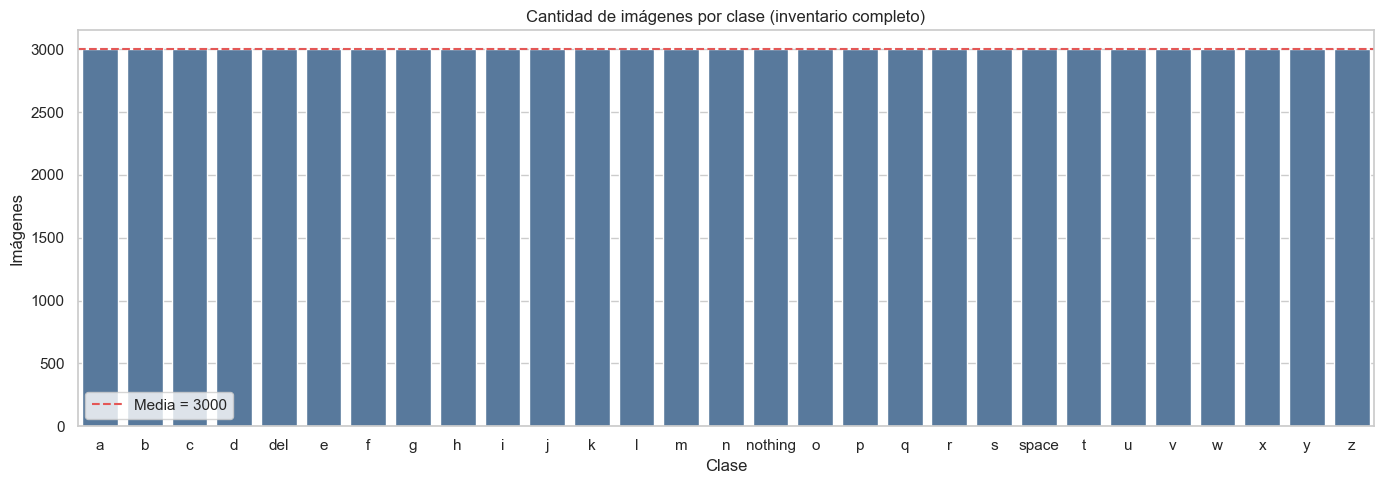

Interpretación: barras de altura similar indican que la exactitud global no estará dominada
por una clase mayoritaria. Si hubiera diferencias grandes, convendría usar métricas por clase.


In [22]:
fig, ax = plt.subplots(figsize=(14, 5))
sns.barplot(x=class_counts.index, y=class_counts.values, color='#4C78A8', ax=ax)
ax.axhline(class_counts.mean(), color='#E45756', linestyle='--', label=f'Media = {class_counts.mean():.0f}')
ax.set(title='Cantidad de imágenes por clase (inventario completo)', xlabel='Clase', ylabel='Imágenes')
ax.legend()
plt.tight_layout(); plt.show()

print('Interpretación: barras de altura similar indican que la exactitud global no estará dominada')
print('por una clase mayoritaria. Si hubiera diferencias grandes, convendría usar métricas por clase.')

## 3. Submuestra para análisis de píxeles

El inventario completo contiene 3,000 imágenes por clase. Para respetar el límite de cómputo se seleccionan **600 imágenes por clase** (17,400 en total, 20% del dataset). Esta cantidad está dentro del rango recomendado de 500-800 y mantiene exactamente la misma representación para las 29 clases.

Los archivos están numerados, por ejemplo `A1.jpg`, `A2.jpg`, etc. Fotografías con números consecutivos pueden proceder de momentos cercanos de captura. Por ello se forman bloques de 30 imágenes consecutivas: un bloque completo pertenece solamente a entrenamiento, validación o prueba. Con semilla 42 se eligen 20 bloques por clase y se asignan 14/3/3 bloques, equivalentes a **420/90/90 imágenes por clase (70%/15%/15%)**.

In [23]:
import re

def sequence_number(path):
    match = re.search(r'(\d+)$', Path(path).stem)
    if not match:
        raise ValueError(f'No se pudo extraer el número de secuencia de {path}')
    return int(match.group(1))

files_df = files_df.copy()
files_df['sequence_number'] = files_df['path'].map(sequence_number)
files_df['block_id'] = (files_df['sequence_number'] - 1) // 30

split_rng = np.random.default_rng(SEED)
split_parts = []
for label, group in files_df.groupby('class', sort=True):
    available_blocks = np.sort(group['block_id'].unique())
    selected_blocks = split_rng.choice(available_blocks, size=20, replace=False)
    split_rng.shuffle(selected_blocks)
    block_assignment = {
        'train': selected_blocks[:14],
        'validation': selected_blocks[14:17],
        'test': selected_blocks[17:20]
    }
    for split_name, block_ids in block_assignment.items():
        part = group[group['block_id'].isin(block_ids)].copy()
        part['split'] = split_name
        split_parts.append(part)

split_df = pd.concat(split_parts, ignore_index=True)
sample_df = split_df.copy()

print(f'Submuestra total: {len(sample_df):,} de {len(files_df):,} imágenes ({len(sample_df)/len(files_df):.1%}).')
print(f'Imágenes por clase: mínimo={sample_df.groupby("class").size().min()}, máximo={sample_df.groupby("class").size().max()}.')
print('Semilla:', SEED, '| tamaño de bloque:', 30)
print('Conteos globales por conjunto:')
print(split_df['split'].value_counts().reindex(['train', 'validation', 'test']))

Submuestra total: 17,400 de 87,000 imágenes (20.0%).
Imágenes por clase: mínimo=600, máximo=600.
Semilla: 42 | tamaño de bloque: 30
Conteos globales por conjunto:
split
train         12180
validation     2610
test           2610
Name: count, dtype: int64


## 4. ¿Qué muestran las imágenes? Ejemplos de las 29 clases

Primero se muestra una imagen de cada clase para verificar visualmente las etiquetas, el encuadre y el fondo. Después se presentan **seis muestras de siete letras diferentes: A, M, N, S, U, V y R**. Esto supera el requisito de cinco letras y permite observar tanto variabilidad dentro de una clase como similitud entre `M/N/S` y `U/V/R`.

`nothing`, `space` y `del` aparecen en la vista general, pero no se cuentan como letras del alfabeto.

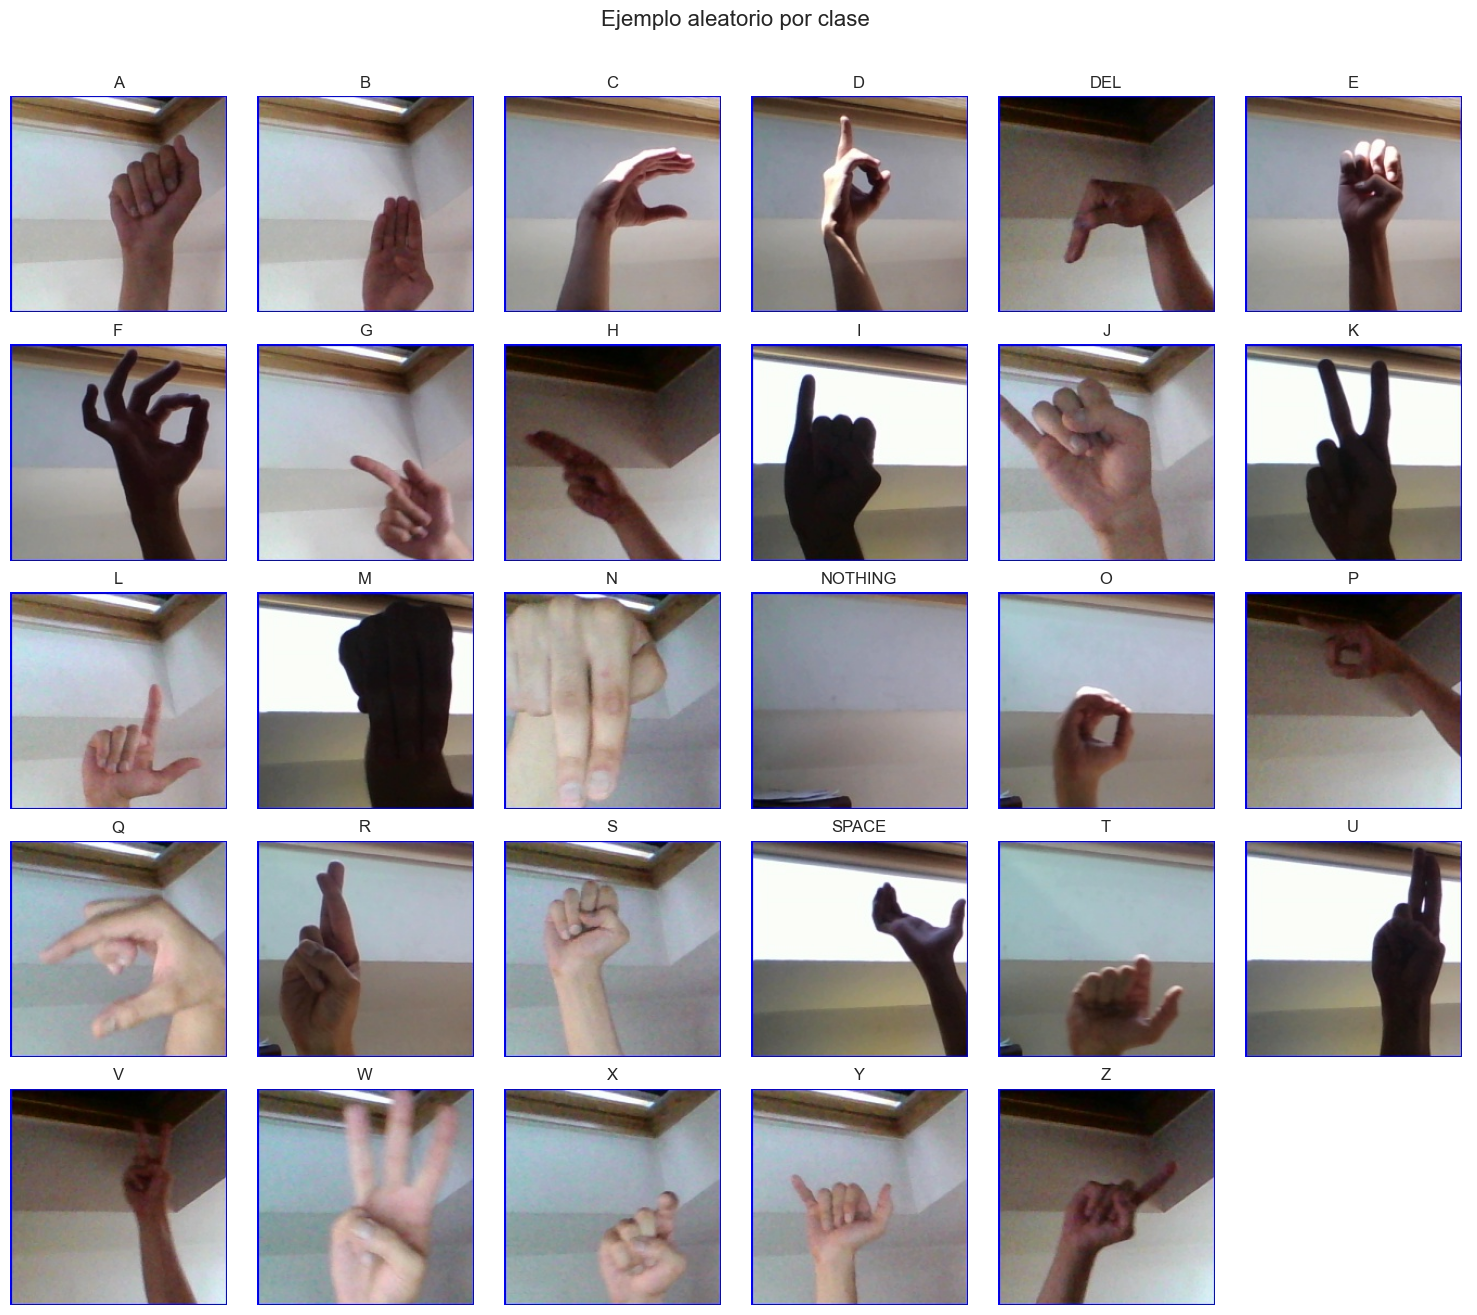

Interpretación: observe si la mano ocupa una región consistente, si el fondo es similar y
si hay clases con siluetas cercanas. Estas regularidades pueden ser atajos visuales para un modelo.


In [24]:
classes = sorted(sample_df['class'].unique())
examples = sample_df.groupby('class', group_keys=False).sample(1, random_state=SEED)
fig, axes = plt.subplots(5, 6, figsize=(15, 13))
for ax in axes.flat:
    ax.axis('off')
for ax, (_, row) in zip(axes.flat, examples.sort_values('class').iterrows()):
    with Image.open(row['path']) as img:
        ax.imshow(img.convert('RGB'))
    ax.set_title(row['class'].upper())
    ax.axis('off')
fig.suptitle('Ejemplo aleatorio por clase', y=1.01, fontsize=16)
plt.tight_layout(); plt.show()

print('Interpretación: observe si la mano ocupa una región consistente, si el fondo es similar y')
print('si hay clases con siluetas cercanas. Estas regularidades pueden ser atajos visuales para un modelo.')

### La imagen como arreglo numérico y canales RGB

Una fotografía a color es un tensor de alto × ancho × 3. Cada canal contiene intensidades entre 0 y 255. Esta inspección conecta el contenido visual con las variables numéricas usadas después y permite confirmar que los colores se codifican correctamente.

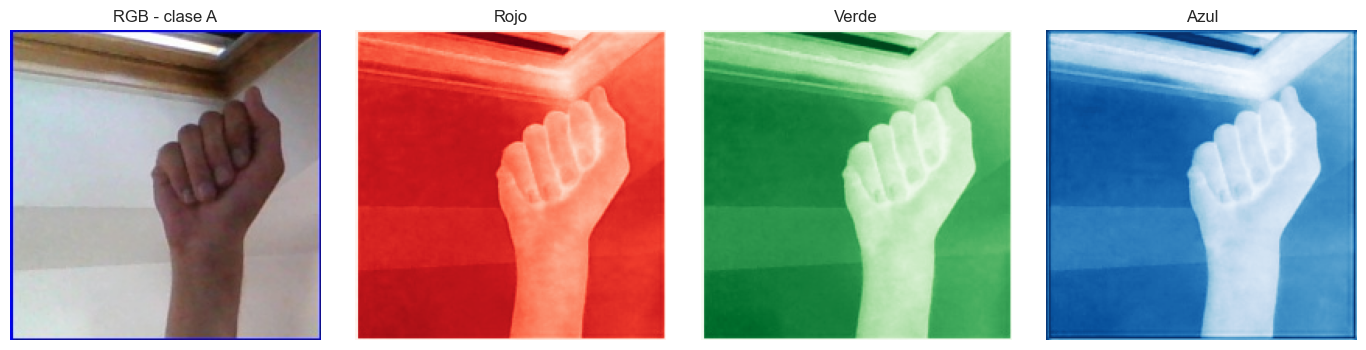

**Recorte numérico 8×8 del canal rojo en el centro de la imagen:**

,0,1,2,3,4,5,6,7
0,115,112,104,98,93,78,92,115
1,119,111,104,98,87,77,83,110
2,124,110,101,94,82,73,72,98
3,115,104,96,91,84,77,77,95
4,112,105,98,92,92,87,89,94
5,115,113,106,98,97,92,93,88
6,115,114,111,104,99,99,96,91
7,119,118,118,111,100,104,95,93


Forma del tensor: (200, 200, 3); tipo: uint8; rango: [0, 255].
Interpretación: los tres canales contienen información de iluminación, piel y fondo;
por eso se analizarán sus medias, pero la forma espacial de la mano sigue siendo esencial.


In [25]:
example_row = examples.sort_values('class').iloc[0]
with Image.open(example_row['path']) as img:
    example_rgb = np.asarray(img.convert('RGB'), dtype=np.uint8)

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
axes[0].imshow(example_rgb)
axes[0].set_title(f"RGB - clase {example_row['class'].upper()}")
for channel, (name, cmap) in enumerate([('Rojo', 'Reds'), ('Verde', 'Greens'), ('Azul', 'Blues')]):
    axes[channel + 1].imshow(example_rgb[..., channel], cmap=cmap, vmin=0, vmax=255)
    axes[channel + 1].set_title(name)
for ax in axes:
    ax.axis('off')
plt.tight_layout(); plt.show()

center_y, center_x = example_rgb.shape[0] // 2, example_rgb.shape[1] // 2
red_patch = example_rgb[center_y-4:center_y+4, center_x-4:center_x+4, 0]
display(Markdown('**Recorte numérico 8×8 del canal rojo en el centro de la imagen:**'))
display(pd.DataFrame(red_patch))
print(f'Forma del tensor: {example_rgb.shape}; tipo: {example_rgb.dtype}; rango: [{example_rgb.min()}, {example_rgb.max()}].')
print('Interpretación: los tres canales contienen información de iluminación, piel y fondo;')
print('por eso se analizarán sus medias, pero la forma espacial de la mano sigue siendo esencial.')

### Variabilidad dentro de una misma clase

El cruce **letra x muestra** presenta seis fotografías por letra. Las filas permiten comparar clases y las columnas muestran cambios de posición, escala, rotación, iluminación y apertura de los dedos dentro de la misma etiqueta.

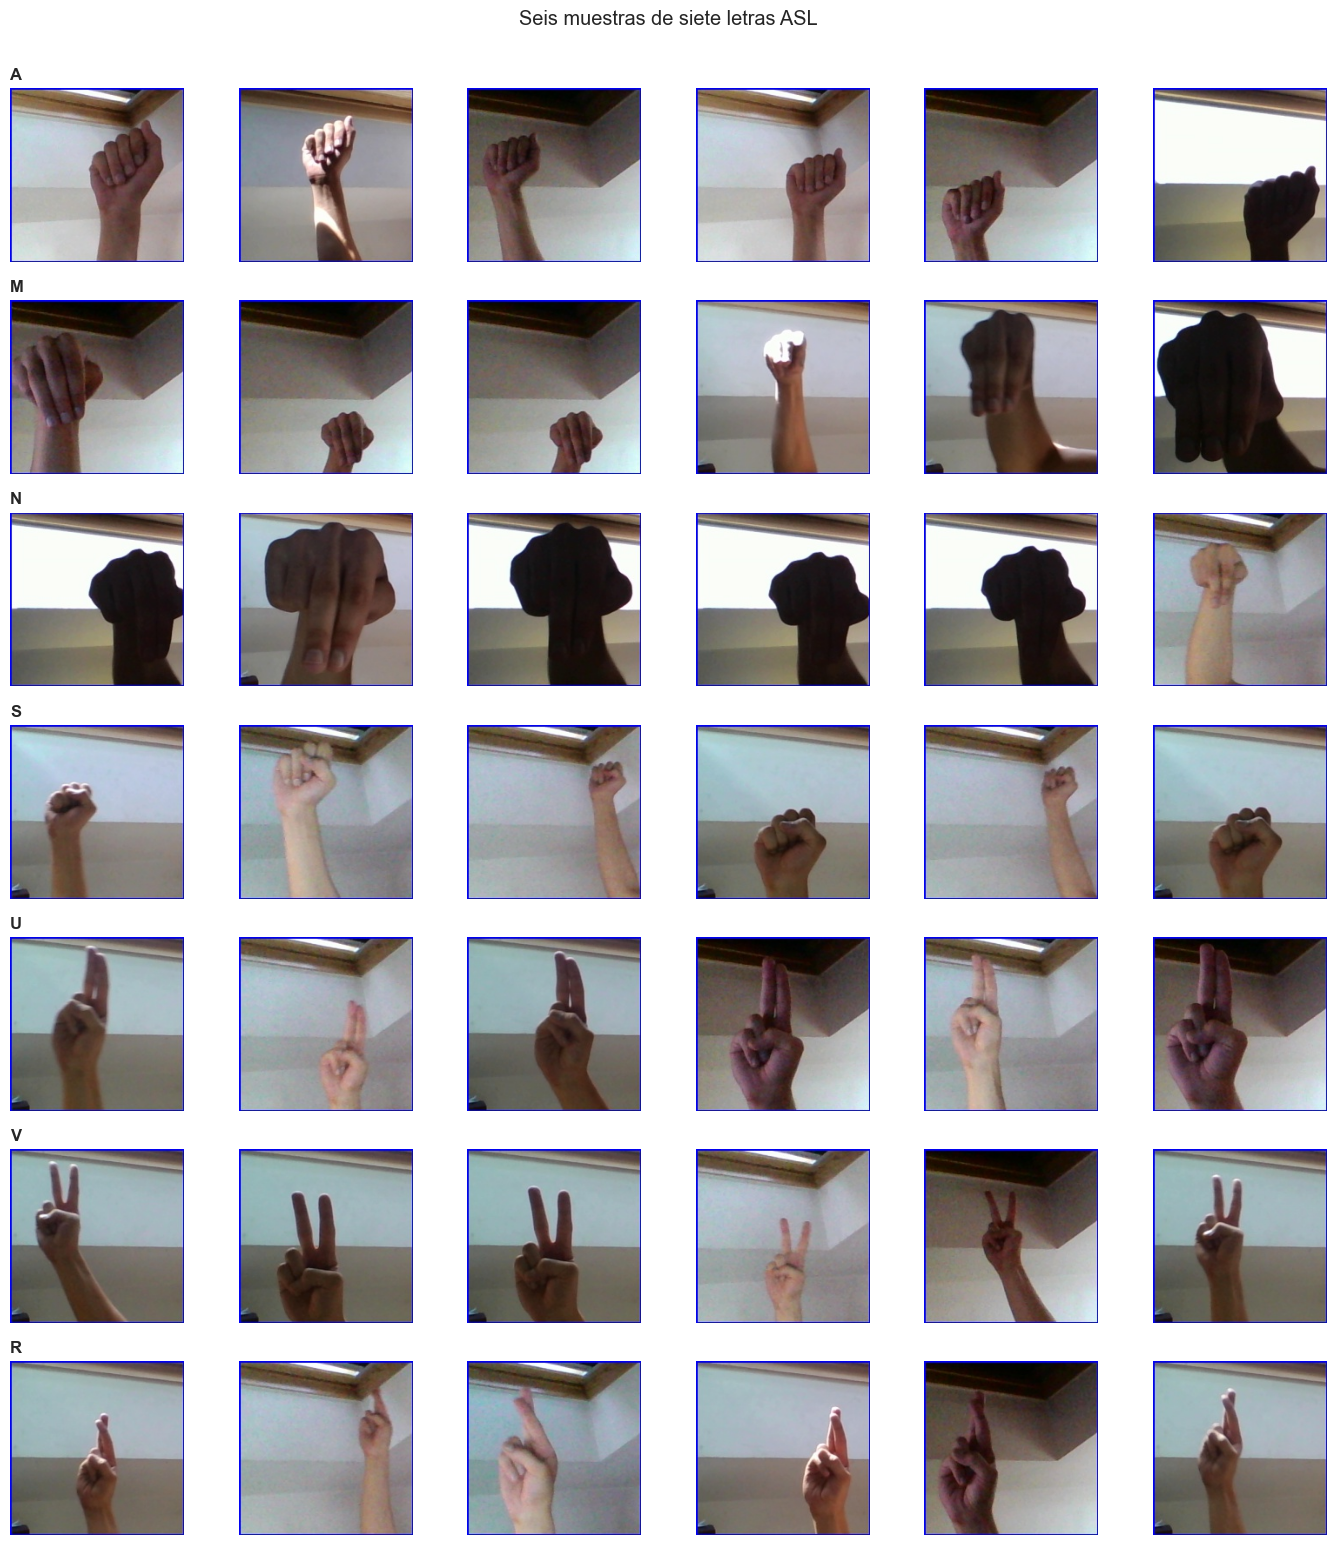

Letras mostradas: A, M, N, S, U, V, R
Muestras por letra: 6
Total de fotografías en esta comparación: 42


In [26]:
focus_classes = [c for c in ['a', 'm', 'n', 's', 'u', 'v', 'r'] if c in classes]
n_examples = 6
fig, axes = plt.subplots(len(focus_classes), n_examples,
                         figsize=(14, 2.2 * len(focus_classes)), squeeze=False)
for row_index, label in enumerate(focus_classes):
    chosen = sample_df[sample_df['class'] == label].sample(n_examples, random_state=SEED + row_index)
    for column_index, (_, row) in enumerate(chosen.iterrows()):
        with Image.open(row['path']) as img:
            axes[row_index, column_index].imshow(img.convert('RGB'))
        axes[row_index, column_index].axis('off')
        if column_index == 0:
            axes[row_index, column_index].set_title(label.upper(), loc='left', fontweight='bold')
plt.suptitle('Seis muestras de siete letras ASL', y=1.002)
plt.tight_layout(); plt.show()

print('Letras mostradas:', ', '.join(label.upper() for label in focus_classes))
print('Muestras por letra:', n_examples)
print('Total de fotografías en esta comparación:', len(focus_classes) * n_examples)

### Hallazgos de la inspección visual

- **Variabilidad dentro de una letra:** cambian ligeramente la posición, escala, rotación, iluminación y apertura de los dedos. La identidad de la seña se mantiene, por lo que un modelo no debe depender de una ubicación exacta de la mano.
- **M/N/S:** comparten una silueta de puño cerrado. La diferencia se concentra en la colocación del pulgar y en cuántos dedos lo cubren; son detalles pequeños que pueden perderse al reducir demasiado la resolución.
- **U/V/R:** usan principalmente dos dedos extendidos. En `U` están juntos, en `V` separados y en `R` cruzados. La rotación o una oclusión puede hacer que estas configuraciones se parezcan.
- **Consecuencia:** se conserva color y una resolución de 64x64, y se evitan filtros agresivos que borren los bordes entre dedos.

## 5. ¿Hay problemas de formato, dimensiones o calidad?

Se decodifica cada imagen de la submuestra y se calculan variables derivadas: dimensiones, modo de color, brillo promedio, contraste (desviación estándar del gris), medias RGB y nitidez aproximada mediante diferencias entre píxeles vecinos. Estas variables convierten contenido visual en cantidades que pueden cruzarse con la clase. También se construye una versión gris 32×32 únicamente para medir similitud y variabilidad.

In [27]:
def image_features(path):
    with Image.open(path) as original:
        width, height = original.size
        file_format, mode = original.format, original.mode
        rgb = np.asarray(original.convert('RGB').resize(EDA_SIZE, Image.Resampling.BILINEAR), dtype=np.float32)
    gray = rgb @ np.array([0.299, 0.587, 0.114], dtype=np.float32)
    dx, dy = np.diff(gray, axis=1), np.diff(gray, axis=0)
    gray32 = np.asarray(Image.fromarray(gray.astype(np.uint8)).resize((32, 32), Image.Resampling.BILINEAR), dtype=np.float32)
    return {
        'width': width, 'height': height, 'mode': mode, 'format': file_format,
        'brightness': float(gray.mean()), 'contrast': float(gray.std()),
        'red_mean': float(rgb[..., 0].mean()), 'green_mean': float(rgb[..., 1].mean()),
        'blue_mean': float(rgb[..., 2].mean()),
        'sharpness': float((np.mean(dx**2) + np.mean(dy**2)) / 2),
        'gray32': gray32.ravel()
    }

feature_rows, bad_files = [], []
for row in tqdm(sample_df.itertuples(index=False), total=len(sample_df), desc='Extrayendo características'):
    try:
        values = image_features(row.path)
        gray32 = values.pop('gray32')
        feature_rows.append({'path': row.path, 'class': row[1], **values, 'gray32': gray32})
    except Exception as exc:
        bad_files.append({'path': str(row.path), 'error': repr(exc)})

features_df = pd.DataFrame(feature_rows)
print(f'Procesadas: {len(features_df):,} | no legibles: {len(bad_files):,}')
display(pd.DataFrame(bad_files).head() if bad_files else Markdown('**No se detectaron archivos dañados en la submuestra.**'))

Extrayendo características:   0%|          | 0/17400 [00:00<?, ?it/s]

Procesadas: 17,400 | no legibles: 0


**No se detectaron archivos dañados en la submuestra.**

In [28]:
format_table = (features_df.groupby(['width', 'height', 'mode', 'format'])
                .size().rename('n').reset_index().sort_values('n', ascending=False))
display(format_table)
standard_pct = 100 * ((features_df['width'] == 200) & (features_df['height'] == 200) &
                      (features_df['mode'] == 'RGB')).mean()
display(Markdown(
    f'**Hallazgo.** El **{standard_pct:.2f}%** de la submuestra cumple simultáneamente 200×200 y RGB. '
    f'Se encontraron **{len(bad_files)}** archivos no legibles. Cualquier excepción debe revisarse '
    'antes de crear un pipeline, pues los lotes de una red requieren dimensiones homogéneas.'
))

,width,height,mode,format,n
0,200,200,RGB,JPEG,17400


**Hallazgo.** El **100.00%** de la submuestra cumple simultáneamente 200×200 y RGB. Se encontraron **0** archivos no legibles. Cualquier excepción debe revisarse antes de crear un pipeline, pues los lotes de una red requieren dimensiones homogéneas.

## 6. Cruces de variables: clase × brillo, contraste, color y nitidez

Los diagramas de caja muestran mediana, dispersión y valores extremos por etiqueta. Si una clase tiene una distribución de iluminación o nitidez distinta, existe riesgo de que un futuro clasificador aprenda condiciones de captura en vez de la forma de la mano. La variabilidad es señal útil para decidir normalización y aumentos de datos.

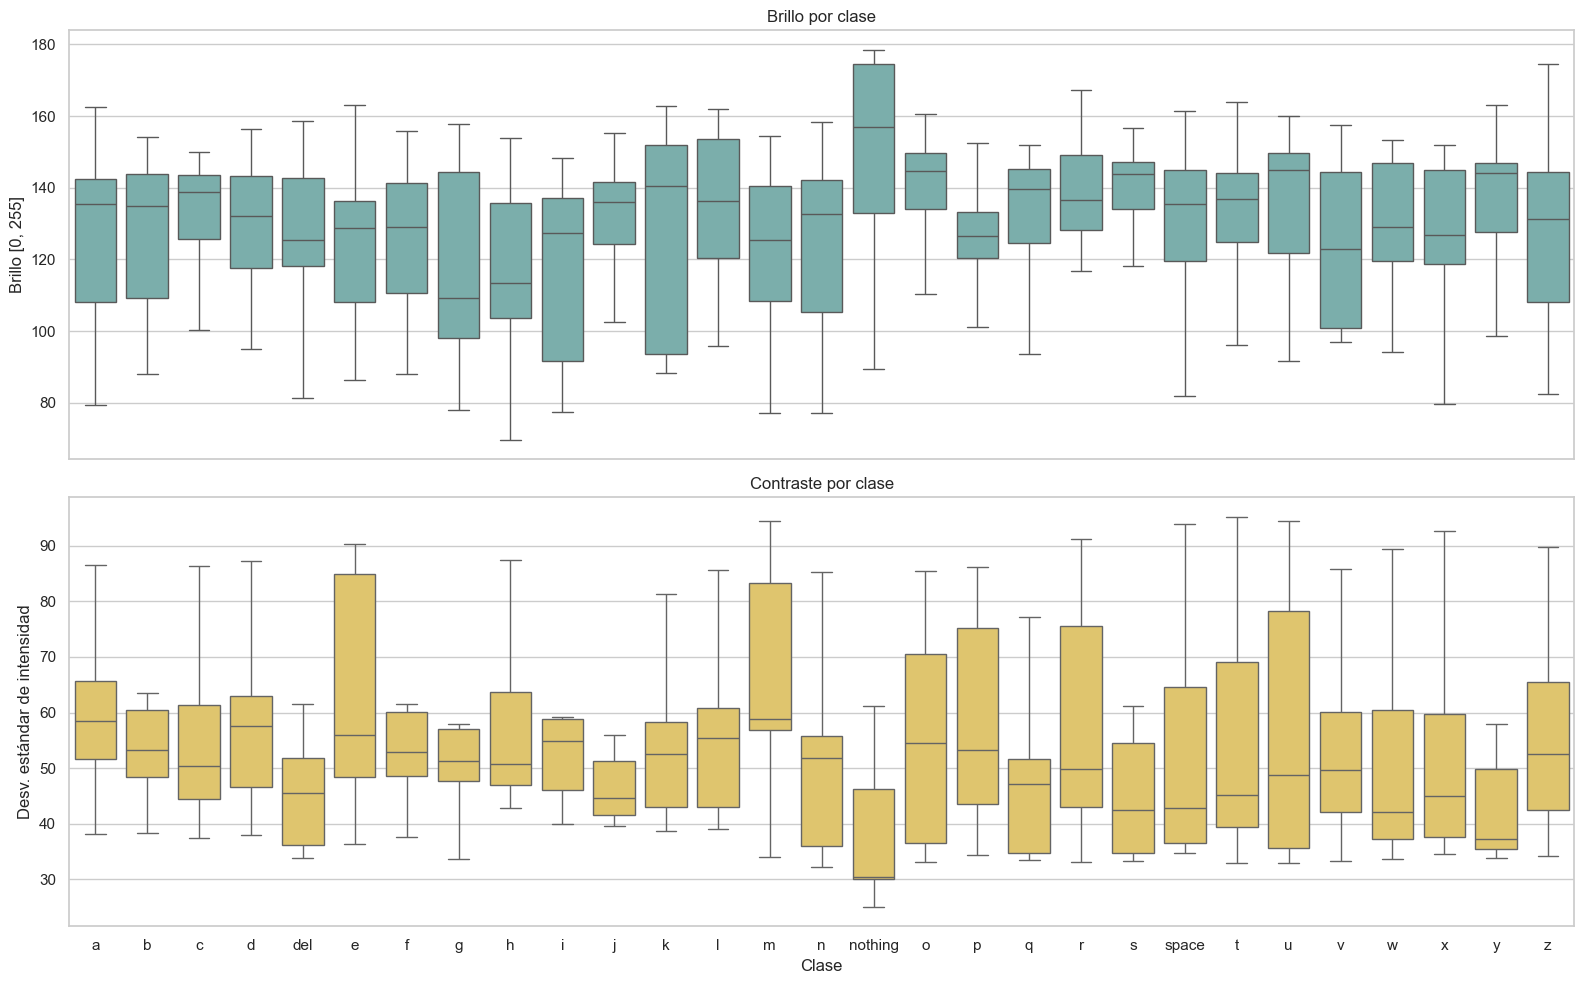

brightness        contrast        sharpness        
              mean    std     mean    std      mean     std
class                                                      
a           126.33  21.66    62.31  14.40    271.68  117.58
b           127.26  20.14    57.28  15.48    259.76  106.60
c           132.83  14.03    56.39  15.24    304.50  121.70
d           128.05  18.00    58.78  15.67    284.77  131.69
del         126.13  20.51    49.62  16.07    226.35  107.26
e           125.78  18.78    63.40  18.75    322.39  119.24
f           126.33  19.37    56.37  14.09    369.33  157.94
g           117.97  24.68    55.73  17.88    255.17  146.39
h           116.73  22.40    58.97  17.32    237.97  138.86
i           118.70  21.66    58.88  17.05    241.42  153.18
j           128.49  20.96    49.55  12.99    210.91   98.46
k           130.05  25.65    55.61  15.24    260.61  145.30
l           133.77  20.61    54.90  14.09    266.94  103.97
m           123.18  19.08    64.03  17.29    282.02  113.23
n           126.52  22.98    50.71  16.77    241.20  102.56
nothing     149.23  27.24    40.34  16.15    121.48   54.26
o           139.18  15.64    55.72  17.74    266.64  121.79
p           126.60  17.92    56.46  16.89    305.97  150.13
q           132.27  18.10    45.65  10.86    216.38  106.43
r           134.04  22.49    55.70  17.78    230.28  114.45
s           137.03  16.77    48.30  17.41    204.60   83.59
space       129.77  18.87    52.50  19.77    262.62  152.09
t           131.16  18.38    55.01  21.41    250.30  143.55
u           134.22  20.31    55.89  20.10    241.50  113.43
v           123.71  19.65    52.70  14.50    202.36  117.22
w           128.89  17.98    51.37  18.30    259.59  182.41
x           125.98  20.47    53.24  19.71    221.57  126.85
y           135.93  19.00    47.14  18.41    234.05  113.71
z           126.07  24.78    56.55  17.05    230.14  137.44

Hallazgo cuantitativo: las medias por clase abarcan 32.5 niveles de brillo y
23.7 puntos de contraste. Rangos grandes sugieren condiciones de captura asociadas a la etiqueta.


In [29]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)
sns.boxplot(data=features_df, x='class', y='brightness', showfliers=False, color='#72B7B2', ax=axes[0])
sns.boxplot(data=features_df, x='class', y='contrast', showfliers=False, color='#F2CF5B', ax=axes[1])
axes[0].set(title='Brillo por clase', xlabel='', ylabel='Brillo [0, 255]')
axes[1].set(title='Contraste por clase', xlabel='Clase', ylabel='Desv. estándar de intensidad')
plt.tight_layout(); plt.show()

class_stats = features_df.groupby('class')[['brightness', 'contrast', 'sharpness']].agg(['mean', 'std']).round(2)
display(class_stats)
bright_range = features_df.groupby('class')['brightness'].mean().agg(lambda s: s.max() - s.min())
contrast_range = features_df.groupby('class')['contrast'].mean().agg(lambda s: s.max() - s.min())
print(f'Hallazgo cuantitativo: las medias por clase abarcan {bright_range:.1f} niveles de brillo y')
print(f'{contrast_range:.1f} puntos de contraste. Rangos grandes sugieren condiciones de captura asociadas a la etiqueta.')

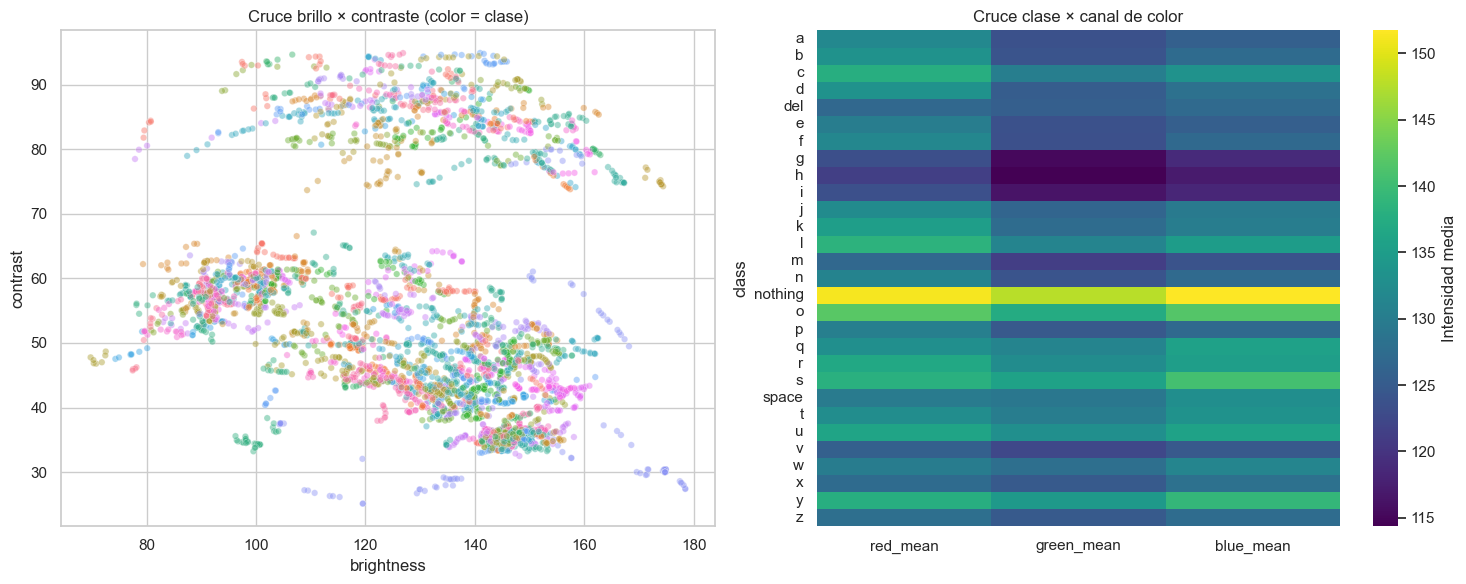

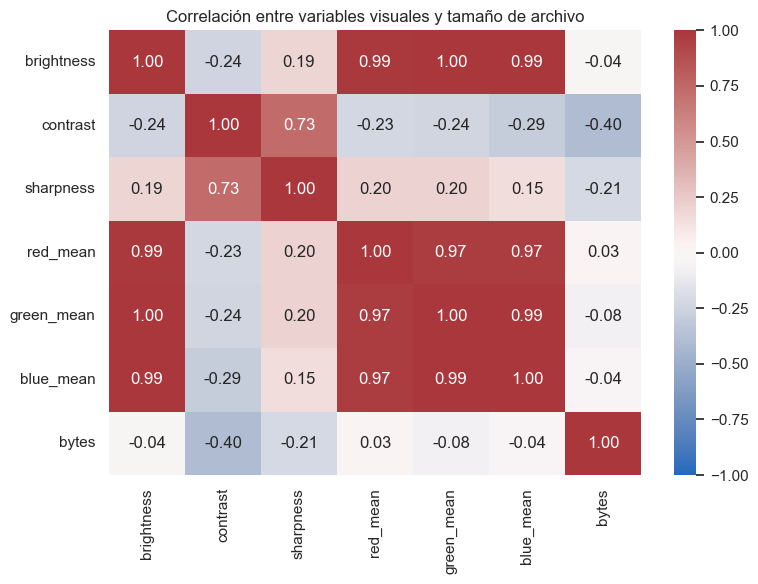

Interpretación: el solapamiento de colores en el dispersograma indica que brillo y contraste
por sí solos no deberían separar las letras. Correlaciones RGB altas son esperables por iluminación compartida.


In [30]:
plot_df = features_df.sample(min(4000, len(features_df)), random_state=SEED)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.scatterplot(data=plot_df, x='brightness', y='contrast', hue='class', palette='husl',
                s=22, alpha=.45, legend=False, ax=axes[0])
axes[0].set_title('Cruce brillo × contraste (color = clase)')
color_means = features_df.groupby('class')[['red_mean', 'green_mean', 'blue_mean']].mean()
sns.heatmap(color_means, cmap='viridis', ax=axes[1], cbar_kws={'label': 'Intensidad media'})
axes[1].set_title('Cruce clase × canal de color')
plt.tight_layout(); plt.show()

numeric_cols = ['brightness', 'contrast', 'sharpness', 'red_mean', 'green_mean', 'blue_mean', 'bytes']
corr_df = features_df.merge(sample_df[['path', 'bytes']], on='path', how='left')[numeric_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_df, annot=True, fmt='.2f', cmap='vlag', center=0, vmin=-1, vmax=1)
plt.title('Correlación entre variables visuales y tamaño de archivo')
plt.tight_layout(); plt.show()
print('Interpretación: el solapamiento de colores en el dispersograma indica que brillo y contraste')
print('por sí solos no deberían separar las letras. Correlaciones RGB altas son esperables por iluminación compartida.')

## 7. ¿Cuánta variabilidad hay dentro de cada clase?

Para cada etiqueta se calcula una imagen gris promedio de 32×32. La distancia absoluta de cada fotografía a ese promedio es una medida sencilla de variabilidad intra-clase: valores altos indican cambios mayores de encuadre, mano, fondo o iluminación. No es una métrica perceptual perfecta, pero sirve como diagnóstico comparativo.

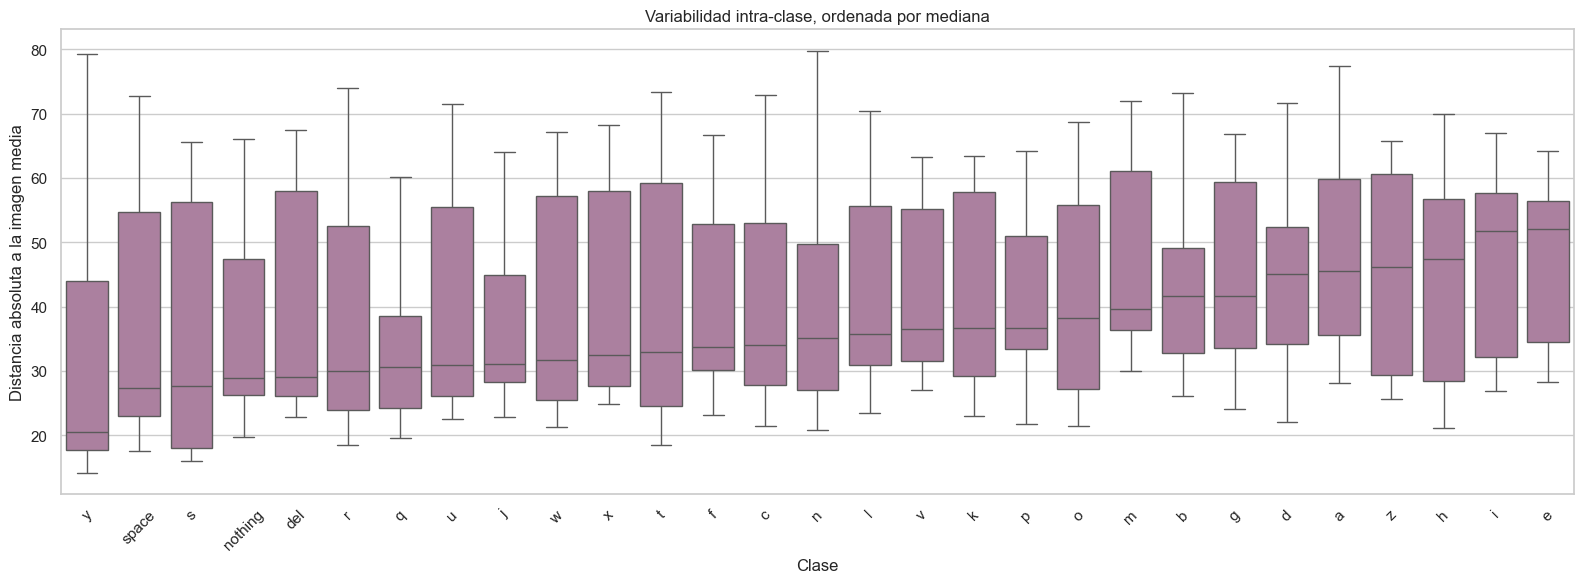

Clases con mayor variabilidad según esta medida:


,mediana_distancia
class,
e,52.110001
i,51.790001
h,47.400002
z,46.119999
a,45.560001


Estas clases merecen inspección manual; la causa puede ser variación genuina o imágenes atípicas.


In [31]:
mean_images = {}
distance_rows = []
for label, group in features_df.groupby('class'):
    stack = np.stack(group['gray32'].to_numpy())
    mean_img = stack.mean(axis=0)
    mean_images[label] = mean_img
    distances = np.mean(np.abs(stack - mean_img), axis=1)
    distance_rows.extend({'class': label, 'distance_to_class_mean': value} for value in distances)
distance_df = pd.DataFrame(distance_rows)

fig, ax = plt.subplots(figsize=(16, 6))
order = distance_df.groupby('class')['distance_to_class_mean'].median().sort_values().index
sns.boxplot(data=distance_df, x='class', y='distance_to_class_mean', order=order,
            showfliers=False, color='#B279A2', ax=ax)
ax.set(title='Variabilidad intra-clase, ordenada por mediana', xlabel='Clase',
       ylabel='Distancia absoluta a la imagen media')
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

variability = distance_df.groupby('class')['distance_to_class_mean'].median().sort_values(ascending=False)
print('Clases con mayor variabilidad según esta medida:')
display(variability.head(5).round(2).to_frame('mediana_distancia'))
print('Estas clases merecen inspección manual; la causa puede ser variación genuina o imágenes atípicas.')

### Imágenes promedio por clase

Al promediar fotografías píxel a píxel, los elementos consistentes permanecen y los que cambian se vuelven borrosos. Si la silueta de una seña sobrevive al promedio, existe una estructura espacial común dentro de esa clase; un fondo muy definido, en cambio, revelaría un posible atajo del dataset.

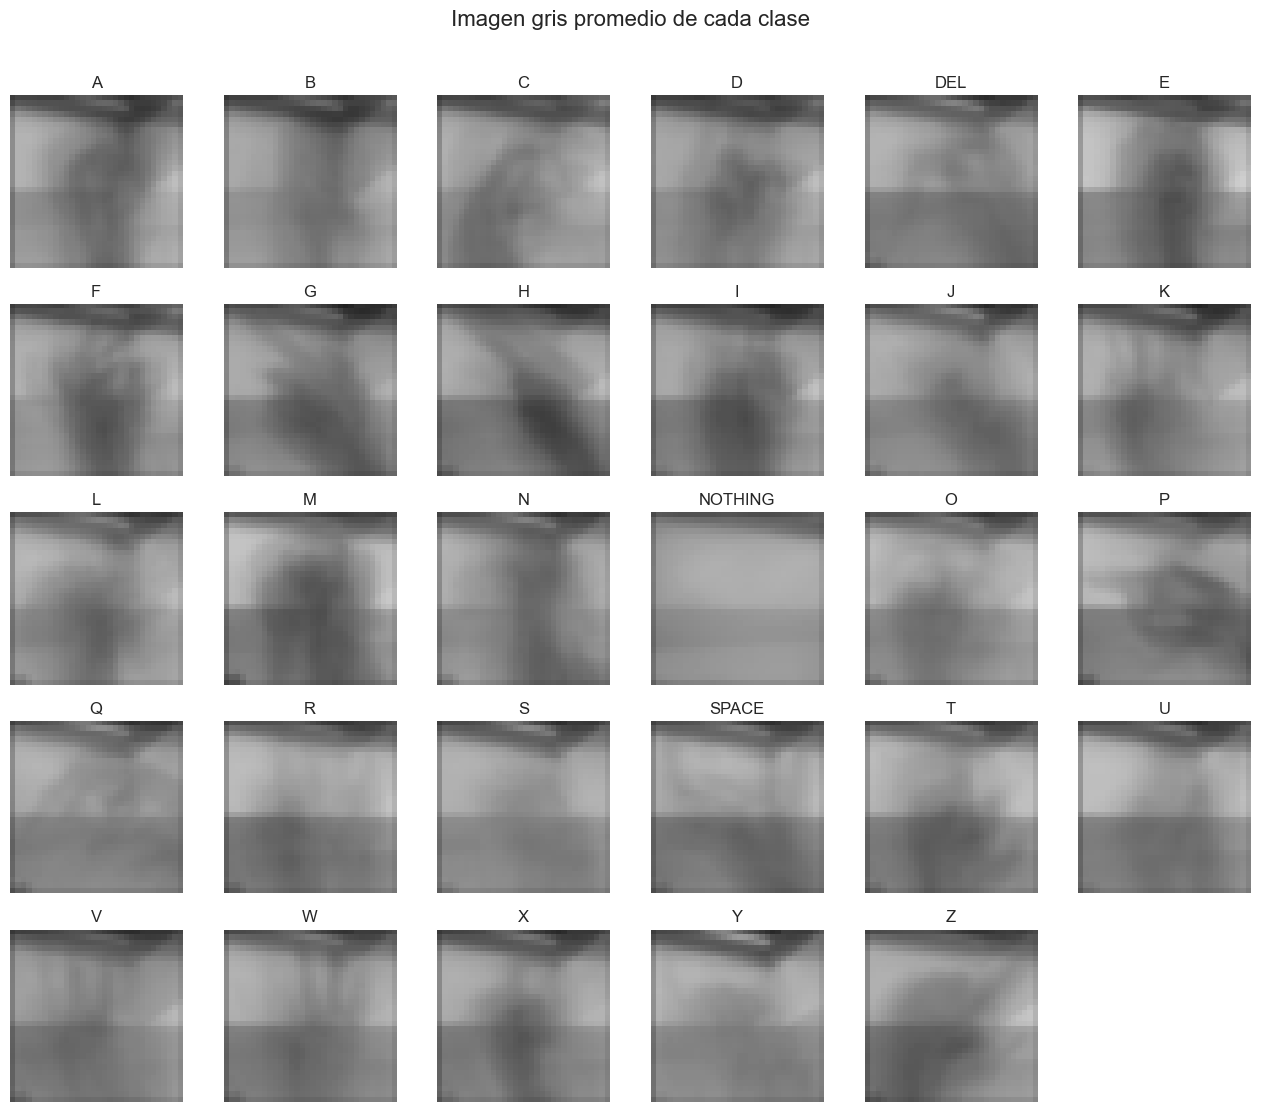

Interpretación: regiones nítidas representan posiciones consistentes; regiones borrosas reflejan
variación de postura o encuadre. Fondos promedio similares sugieren un protocolo de captura común.


In [32]:
fig, axes = plt.subplots(5, 6, figsize=(13, 11))
for ax in axes.flat:
    ax.axis('off')
for ax, label in zip(axes.flat, sorted(mean_images)):
    ax.imshow(mean_images[label].reshape(32, 32), cmap='gray', vmin=0, vmax=255)
    ax.set_title(label.upper())
    ax.axis('off')
fig.suptitle('Imagen gris promedio de cada clase', y=1.01, fontsize=16)
plt.tight_layout(); plt.show()

print('Interpretación: regiones nítidas representan posiciones consistentes; regiones borrosas reflejan')
print('variación de postura o encuadre. Fondos promedio similares sugieren un protocolo de captura común.')

## 8. ¿Qué clases podrían confundirse visualmente?

Se compara la imagen promedio de cada clase usando similitud coseno. Valores altos señalan apariencia global parecida, aunque el fondo compartido también eleva la similitud; por eso este resultado genera hipótesis y no demuestra confusión de un modelo.

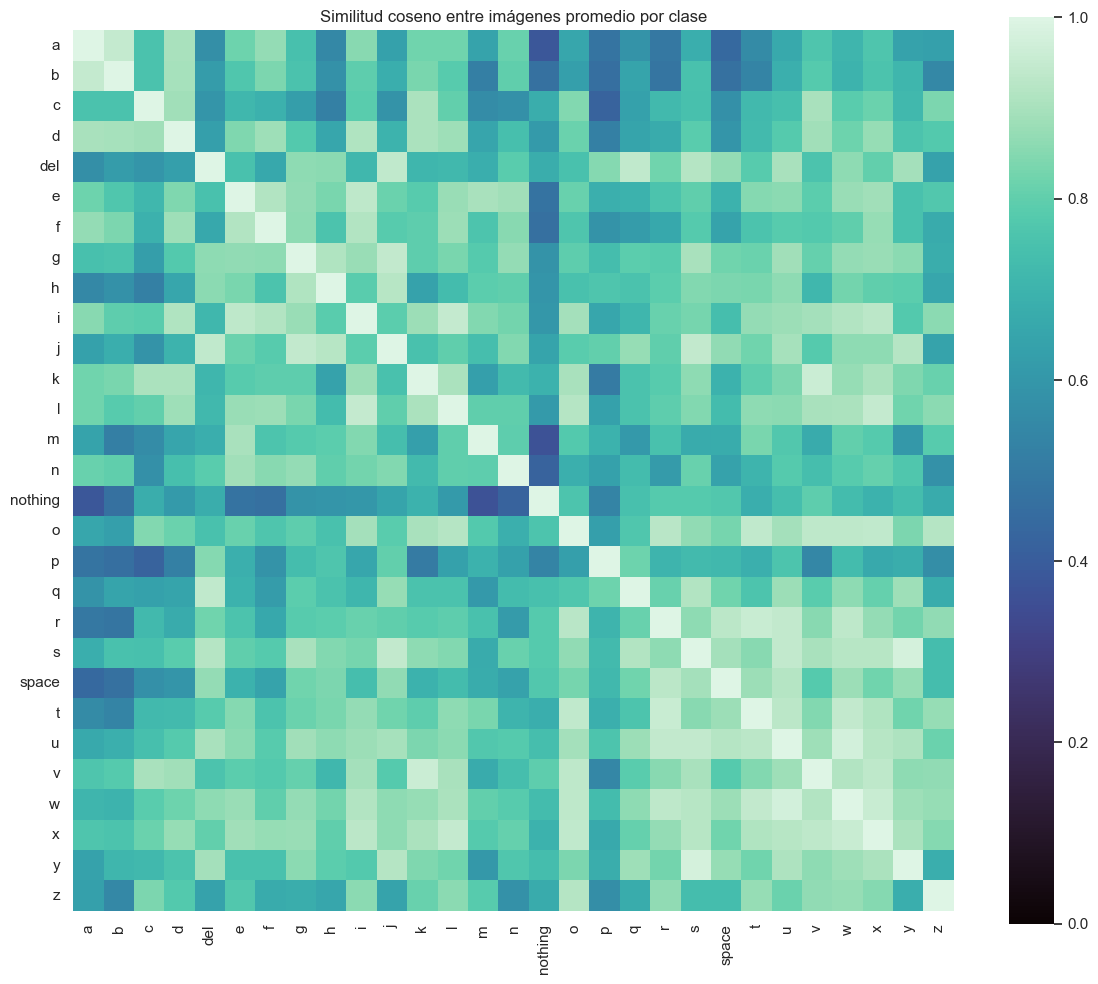

,class_1,class_2,similarity
376,s,y,0.980
392,u,w,0.974
265,k,v,0.959
400,w,x,0.954
363,r,t,0.954
283,l,x,0.949
218,i,l,0.949
0,a,b,0.948
387,t,w,0.945
372,s,u,0.945


Hallazgo: estos pares son candidatos prioritarios para revisar después mediante una matriz de confusión,
pero la similitud promedio puede deberse tanto al gesto como a fondos y posiciones compartidos.


In [33]:
labels = sorted(mean_images)
M = np.stack([mean_images[label] for label in labels])
M_centered = M - M.mean(axis=1, keepdims=True)
norms = np.linalg.norm(M_centered, axis=1, keepdims=True) + 1e-9
similarity = (M_centered / norms) @ (M_centered / norms).T
sim_df = pd.DataFrame(similarity, index=labels, columns=labels)

plt.figure(figsize=(12, 10))
sns.heatmap(sim_df, cmap='mako', vmin=0, vmax=1, square=True)
plt.title('Similitud coseno entre imágenes promedio por clase')
plt.tight_layout(); plt.show()

pairs = []
for i in range(len(labels)):
    for j in range(i + 1, len(labels)):
        pairs.append((labels[i], labels[j], similarity[i, j]))
top_pairs = pd.DataFrame(pairs, columns=['class_1', 'class_2', 'similarity']).nlargest(10, 'similarity')
display(top_pairs.round(3))
print('Hallazgo: estos pares son candidatos prioritarios para revisar después mediante una matriz de confusión,')
print('pero la similitud promedio puede deberse tanto al gesto como a fondos y posiciones compartidos.')

### ¿Cómo se definieron entrenamiento, validación y prueba?

El pequeño set oficial de Kaggle tiene solo 28 imágenes y no incluye `del`; no es suficiente como prueba representativa. Por eso la prueba principal se deriva del entrenamiento disponible.

- **Entrenamiento (70%):** 420 imágenes por clase; se utilizará para ajustar el modelo.
- **Validación (15%):** 90 por clase; servirá para seleccionar configuraciones y vigilar sobreajuste.
- **Prueba (15%):** 90 por clase; permanecerá aislada hasta la evaluación final.

La asignación se hace antes de cualquier aumento de datos. Un bloque de 30 archivos consecutivos nunca se divide entre conjuntos, reduciendo la fuga causada por fotografías cercanas. Esta estrategia no garantiza separación por persona porque el dataset no proporciona identificadores de sujeto o sesión; esa limitación debe conservarse en el informe.

Resumen global de la partición:
            images  classes  percentage
split                                  
train        12180       29        70.0
validation    2610       29        15.0
test          2610       29        15.0

Conteo por clase y conjunto (primeras cinco clases):
split  train  validation  test
class                         
a        420          90    90
b        420          90    90
c        420          90    90
d        420          90    90
del      420          90    90

Rango de conteos por clase:
  train: min=420, max=420
  validation: min=90, max=90
  test: min=90, max=90
Bloques presentes en más de un conjunto: 0
Rutas repetidas entre conjuntos: 0


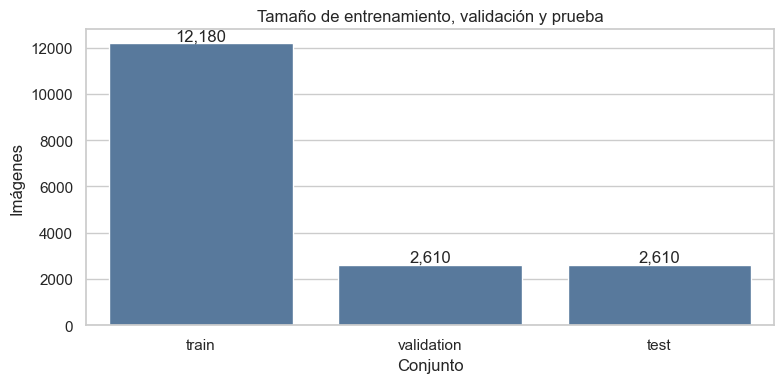

In [34]:
split_order = ['train', 'validation', 'test']
split_summary = split_df.groupby('split').agg(
    images=('path', 'size'),
    classes=('class', 'nunique')
).reindex(split_order)
split_summary['percentage'] = (100 * split_summary['images'] / len(split_df)).round(1)

per_class_split = split_df.groupby(['class', 'split']).size().unstack().reindex(columns=split_order)
blocks_in_multiple_splits = (split_df.groupby(['class', 'block_id'])['split'].nunique() > 1).sum()
path_overlap = (
    len(set(split_df.loc[split_df['split']=='train', 'path']) & set(split_df.loc[split_df['split']=='validation', 'path'])) +
    len(set(split_df.loc[split_df['split']=='train', 'path']) & set(split_df.loc[split_df['split']=='test', 'path'])) +
    len(set(split_df.loc[split_df['split']=='validation', 'path']) & set(split_df.loc[split_df['split']=='test', 'path']))
)

print('Resumen global de la partición:')
print(split_summary.to_string())
print('\nConteo por clase y conjunto (primeras cinco clases):')
print(per_class_split.head().to_string())
print('\nRango de conteos por clase:')
for split_name in split_order:
    print(f'  {split_name}: min={per_class_split[split_name].min()}, max={per_class_split[split_name].max()}')
print('Bloques presentes en más de un conjunto:', blocks_in_multiple_splits)
print('Rutas repetidas entre conjuntos:', path_overlap)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=split_summary.reset_index(), x='split', y='images', color='#4C78A8', ax=ax)
ax.set(title='Tamaño de entrenamiento, validación y prueba', xlabel='Conjunto', ylabel='Imágenes')
for patch, value in zip(ax.patches, split_summary['images']):
    ax.text(patch.get_x()+patch.get_width()/2, value, f'{value:,}', ha='center', va='bottom')
plt.tight_layout(); plt.show()

## 9. Impacto de reducir la resolución a 64×64

La reducción propuesta mantiene color RGB y baja el número de valores por imagen de 120,000 a 12,288. Se muestran los mismos ejemplos en ambas resoluciones para comprobar si aún son distinguibles los dedos y la silueta. Esta inspección es necesaria: el ahorro no justifica perder el detalle que separa clases cercanas.

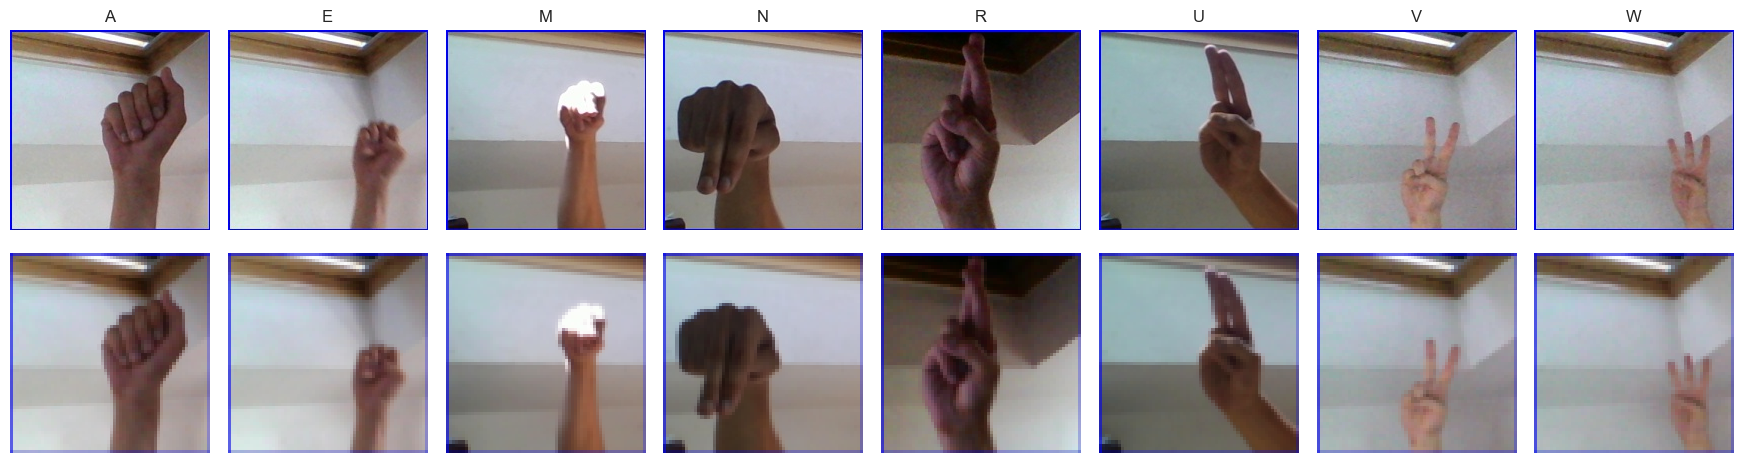

**Resultado.** 64×64 reduce **89.8%** los valores por imagen. El dataset completo a 200×200 RGB ocuparía aproximadamente **9.72 GiB** sin compresión en memoria, mientras esta submuestra a 64×64 requeriría **0.20 GiB** como `uint8` (sin contar estructuras auxiliares). La figura permite verificar el costo visual.

In [35]:
comparison_classes = [c for c in ['a', 'e', 'm', 'n', 'r', 'u', 'v', 'w'] if c in classes]
comparison = sample_df[sample_df['class'].isin(comparison_classes)].groupby('class').sample(1, random_state=SEED)
fig, axes = plt.subplots(2, len(comparison), figsize=(2.2 * len(comparison), 5), squeeze=False)
for j, (_, row) in enumerate(comparison.sort_values('class').iterrows()):
    with Image.open(row['path']) as img:
        rgb = img.convert('RGB')
        reduced = rgb.resize(EDA_SIZE, Image.Resampling.BILINEAR)
    axes[0, j].imshow(rgb); axes[1, j].imshow(reduced)
    axes[0, j].set_title(row['class'].upper())
    axes[0, j].axis('off'); axes[1, j].axis('off')
axes[0, 0].set_ylabel('200×200'); axes[1, 0].set_ylabel('64×64')
plt.tight_layout(); plt.show()

original_values = 200 * 200 * 3
reduced_values = 64 * 64 * 3
saving = 1 - reduced_values / original_values
full_raw_gb = len(files_df) * original_values / 1024**3
sample_raw_gb = len(sample_df) * reduced_values / 1024**3
display(Markdown(
    f'**Resultado.** 64×64 reduce **{saving:.1%}** los valores por imagen. '
    f'El dataset completo a 200×200 RGB ocuparía aproximadamente **{full_raw_gb:.2f} GiB** '
    f'sin compresión en memoria, mientras esta submuestra a 64×64 requeriría **{sample_raw_gb:.2f} GiB** '
    'como `uint8` (sin contar estructuras auxiliares). La figura permite verificar el costo visual.'
))

### Pipeline completo de preprocesamiento antes de entrenar

**Pregunta:** ¿cómo se transforman las fotografías para reducir el costo sin destruir los detalles que distinguen las letras?

Cada archivo original es JPEG RGB de 200x200. El pipeline propuesto realiza, en este orden:

1. Corregir orientación EXIF si existe y convertir explícitamente a RGB.
2. Reducir a **64x64** mediante interpolación bilineal.
3. Convertir el arreglo a `float32`.
4. Normalizar cada canal dividiendo entre 255, por lo que los píxeles quedan en `[0,1]`.

**Filtros:** no se aplica desenfoque, enfoque artificial ni segmentación de fondo. Estos filtros pueden borrar o exagerar los espacios entre dedos, precisamente donde se diferencian `M/N/S` y `U/V/R`.

**Aumentos futuros:** durante entrenamiento solamente se podrían usar rotaciones pequeñas, traslaciones, zoom y cambios leves de brillo. Nunca deben aplicarse antes de la partición ni guardarse copias aumentadas en validación/prueba.

### Evidencia del pipeline de preprocesamiento

La siguiente función aplica exactamente las transformaciones documentadas. Se prueban cinco letras y se imprimen forma, tipo y rango antes/después; así los valores del informe provienen del código y no de una suposición.

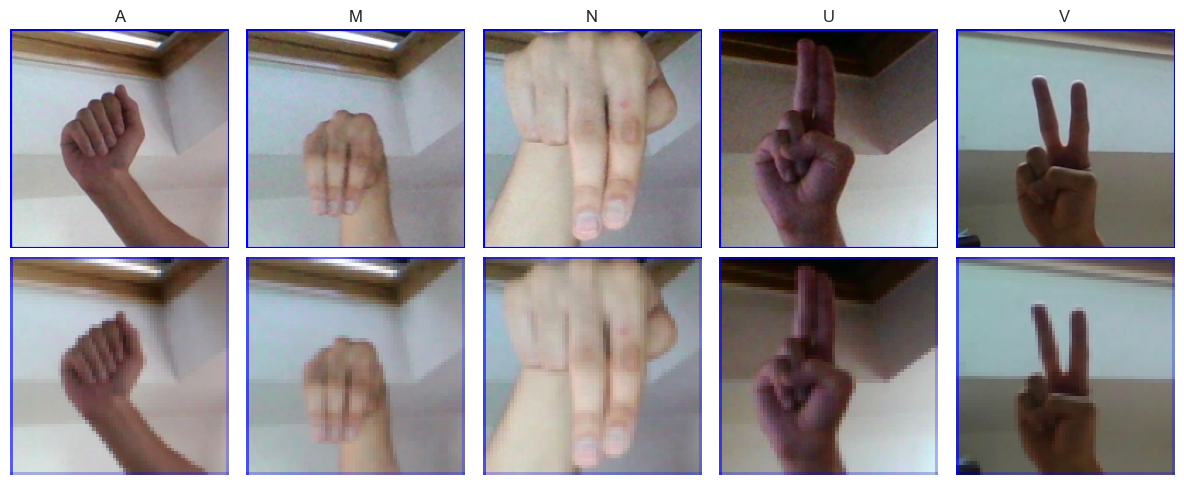

Cantidad de ejemplos procesados: 5
Forma original de una imagen: (200, 200, 3)
Tipo original: uint8 | rango: 0 a 255
Forma del lote procesado: (5, 64, 64, 3)
Tipo procesado: float32
Rango procesado: 0.0000 a 0.9922
Canales conservados: 3 (RGB)


In [36]:
def preprocess_image(path, target_size=EDA_SIZE):
    with Image.open(path) as image:
        image = ImageOps.exif_transpose(image).convert('RGB')
        original_array = np.asarray(image, dtype=np.uint8)
        resized = image.resize(target_size, Image.Resampling.BILINEAR)
        normalized = np.asarray(resized, dtype=np.float32) / 255.0
    return original_array, normalized

preprocess_letters = ['a', 'm', 'n', 'u', 'v']
preprocess_examples = (split_df[
    (split_df['split'] == 'train') & split_df['class'].isin(preprocess_letters)
].groupby('class').sample(1, random_state=SEED).sort_values('class'))

fig, axes = plt.subplots(2, len(preprocess_examples), figsize=(12, 5), squeeze=False)
processed_arrays = []
for column, (_, row) in enumerate(preprocess_examples.iterrows()):
    original_array, normalized = preprocess_image(row['path'])
    processed_arrays.append(normalized)
    axes[0, column].imshow(original_array)
    axes[1, column].imshow(normalized)
    axes[0, column].set_title(row['class'].upper())
    axes[0, column].axis('off'); axes[1, column].axis('off')
axes[0, 0].set_ylabel('Original\n200x200')
axes[1, 0].set_ylabel('Procesada\n64x64')
plt.tight_layout(); plt.show()

preview_batch = np.stack(processed_arrays)
print('Cantidad de ejemplos procesados:', len(preview_batch))
print('Forma original de una imagen:', original_array.shape)
print('Tipo original:', original_array.dtype, '| rango:', int(original_array.min()), 'a', int(original_array.max()))
print('Forma del lote procesado:', preview_batch.shape)
print('Tipo procesado:', preview_batch.dtype)
print(f'Rango procesado: {preview_batch.min():.4f} a {preview_batch.max():.4f}')
print('Canales conservados:', preview_batch.shape[-1], '(RGB)')

### Justificación final del preprocesamiento

- La submuestra reduce el entrenamiento potencial de 87,000 a 17,400 imágenes sin introducir desbalance.
- El cambio de 200x200 a 64x64 reduce 89.8% de los valores por imagen y conserva visualmente la silueta y separación de dedos en los ejemplos.
- La normalización `[0,255] -> [0,1]` evita que la escala de entrada sea innecesariamente grande y mantiene la relación entre canales.
- No se sobrescriben los JPEG originales: el cambio se realiza al cargarlos, permitiendo modificar el pipeline sin perder información.
- Validación y prueba reciben solamente corrección EXIF, RGB, redimensionamiento y normalización; cualquier aumento aleatorio queda reservado para entrenamiento.

## 10. Imágenes extremas: control visual de calidad

Los valores extremos pueden ser casos reales difíciles o problemas de captura. Se muestran las imágenes con menor/mayor brillo, contraste y nitidez; no deben eliminarse automáticamente sin inspección, porque hacerlo puede reducir la capacidad de generalización.

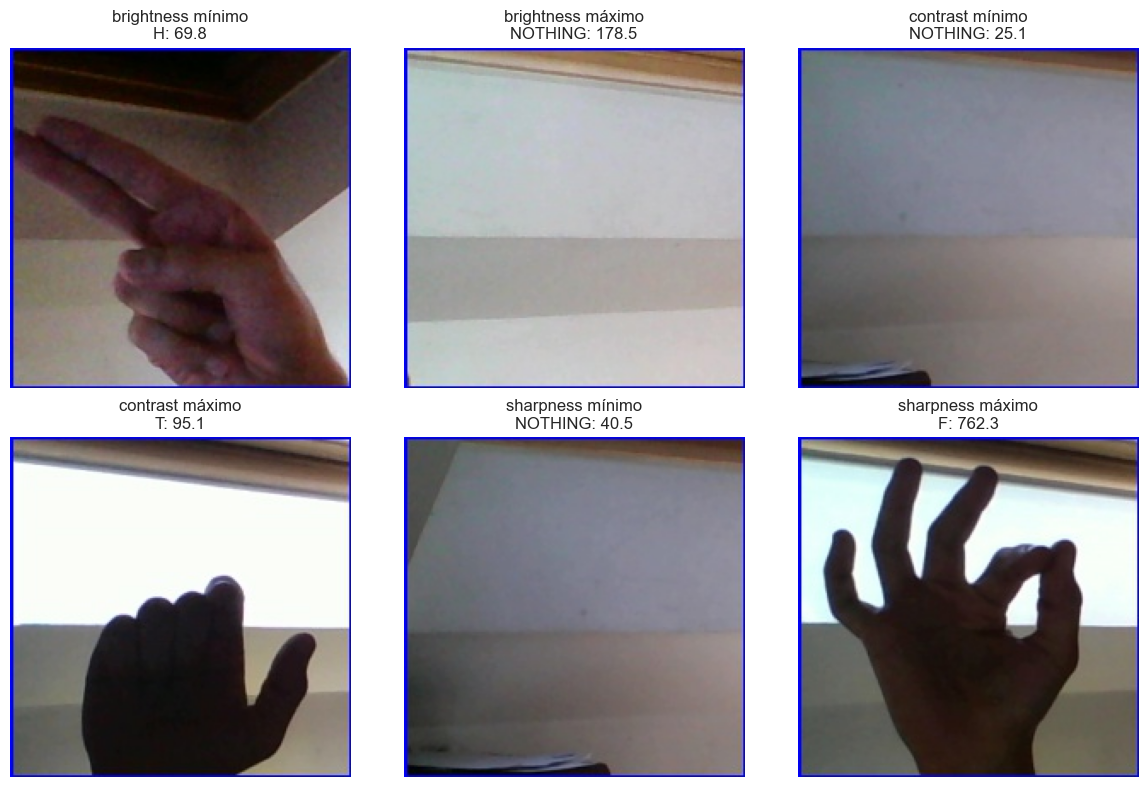

Interpretación: revise si los extremos todavía contienen una mano y una etiqueta plausible.
Conservar extremos válidos es importante para que el sistema funcione fuera de condiciones ideales.


In [37]:
extremes = []
for metric in ['brightness', 'contrast', 'sharpness']:
    for side, idx in [('mínimo', features_df[metric].idxmin()), ('máximo', features_df[metric].idxmax())]:
        row = features_df.loc[idx]
        extremes.append((metric, side, row))
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, (metric, side, row) in zip(axes.flat, extremes):
    with Image.open(row['path']) as img:
        ax.imshow(img.convert('RGB'))
    ax.set_title('{} {}\n{}: {:.1f}'.format(metric, side, row['class'].upper(), row[metric]))
    ax.axis('off')
plt.tight_layout(); plt.show()
print('Interpretación: revise si los extremos todavía contienen una mano y una etiqueta plausible.')
print('Conservar extremos válidos es importante para que el sistema funcione fuera de condiciones ideales.')

## 11. Conclusiones y consecuencias para etapas posteriores


In [38]:
most_variable = ', '.join(variability.head(3).index.str.upper())
closest_pairs = ', '.join((top_pairs['class_1'].str.upper() + '–' + top_pairs['class_2'].str.upper()).head(3))
conclusions = f'''
### Resumen de hallazgos

- **Estructura:** se inventariaron **{len(files_df):,} imágenes** en **{class_counts.size} clases**. Las 26 letras conviven con `DEL`, `NOTHING` y `SPACE`, que cumplen una función distinta y deben mantenerse como etiquetas explícitas si el producto necesita comandos en tiempo real.
- **Balance:** la razón entre la clase mayor y la menor fue **{imbalance_ratio:.3f}**. Un valor cercano a 1 indica que el conteo no introduce un desbalance sustancial; aun así, deben reportarse métricas por clase.
- **Calidad técnica:** **{standard_pct:.2f}%** de la submuestra fue RGB de 200×200 y hubo **{len(bad_files)}** archivos no legibles.
- **Variabilidad:** según la distancia a la imagen promedio, las clases más variables fueron **{most_variable}**. Conviene revisar sus ejemplos y usar aumentos realistas de iluminación, traslación y rotación en una etapa de modelado.
- **Similitud entre clases:** los pares promedio más parecidos fueron **{closest_pairs}**. Son hipótesis de confusión, no resultados de clasificación; deberán contrastarse después con precisión/recall y matriz de confusión.
- **Preprocesamiento justificado:** se analizaron hasta **{SAMPLE_PER_CLASS} imágenes por clase** con semilla {SEED}, y se propone 64×64 porque reduce **{saving:.1%}** los valores respecto de 200×200. La inspección visual anterior determina si el detalle de dedos sigue siendo suficiente.
- **Partición propia:** entrenamiento contiene **{int(split_summary.loc['train', 'images']):,}** imágenes, validación **{int(split_summary.loc['validation', 'images']):,}** y prueba **{int(split_summary.loc['test', 'images']):,}**. Cada clase aporta 420/90/90 ejemplos; hubo **{blocks_in_multiple_splits}** bloques compartidos y **{path_overlap}** rutas repetidas entre conjuntos.
- **Riesgo de fuga:** fotografías consecutivas del mismo contexto pueden ser casi idénticas. Una división aleatoria puede colocar capturas vecinas en entrenamiento y prueba e inflar el rendimiento. Si no existen identificadores de persona o sesión, se deben buscar secuencias/duplicados y documentar esta limitación.
- **Validez externa:** fondos, iluminación y manos poco diversas pueden hacer que el desempeño dentro del dataset no represente usuarios reales. Un conjunto de prueba propio debe incluir personas, fondos, distancias e iluminación no observados durante entrenamiento.
- **Limitación de J y Z:** en el uso real estas letras implican movimiento, mientras aquí se representan con fotografías estáticas. Un clasificador de una sola imagen no modelará la trayectoria temporal; el alcance del producto debe declararlo.

'''
display(Markdown(conclusions))


### Resumen de hallazgos

- **Estructura:** se inventariaron **87,000 imágenes** en **29 clases**. Las 26 letras conviven con `DEL`, `NOTHING` y `SPACE`, que cumplen una función distinta y deben mantenerse como etiquetas explícitas si el producto necesita comandos en tiempo real.
- **Balance:** la razón entre la clase mayor y la menor fue **1.000**. Un valor cercano a 1 indica que el conteo no introduce un desbalance sustancial; aun así, deben reportarse métricas por clase.
- **Calidad técnica:** **100.00%** de la submuestra fue RGB de 200×200 y hubo **0** archivos no legibles.
- **Variabilidad:** según la distancia a la imagen promedio, las clases más variables fueron **E, I, H**. Conviene revisar sus ejemplos y usar aumentos realistas de iluminación, traslación y rotación en una etapa de modelado.
- **Similitud entre clases:** los pares promedio más parecidos fueron **S–Y, U–W, K–V**. Son hipótesis de confusión, no resultados de clasificación; deberán contrastarse después con precisión/recall y matriz de confusión.
- **Preprocesamiento justificado:** se analizaron hasta **600 imágenes por clase** con semilla 42, y se propone 64×64 porque reduce **89.8%** los valores respecto de 200×200. La inspección visual anterior determina si el detalle de dedos sigue siendo suficiente.
- **Partición propia:** entrenamiento contiene **12,180** imágenes, validación **2,610** y prueba **2,610**. Cada clase aporta 420/90/90 ejemplos; hubo **0** bloques compartidos y **0** rutas repetidas entre conjuntos.
- **Riesgo de fuga:** fotografías consecutivas del mismo contexto pueden ser casi idénticas. Una división aleatoria puede colocar capturas vecinas en entrenamiento y prueba e inflar el rendimiento. Si no existen identificadores de persona o sesión, se deben buscar secuencias/duplicados y documentar esta limitación.
- **Validez externa:** fondos, iluminación y manos poco diversas pueden hacer que el desempeño dentro del dataset no represente usuarios reales. Un conjunto de prueba propio debe incluir personas, fondos, distancias e iluminación no observados durante entrenamiento.
- **Limitación de J y Z:** en el uso real estas letras implican movimiento, mientras aquí se representan con fotografías estáticas. Un clasificador de una sola imagen no modelará la trayectoria temporal; el alcance del producto debe declararlo.

